In [ ]:
import pandas as pd
import numpy as np

In [ ]:
PATH = '../data'
TARGET = 'SalePrice'

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
df = pd.read_csv(PATH + '/train.csv')

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, shuffle=True, random_state=42
)

train_ids = X_train.pop('Id')
test_ids = X_test.pop('Id')

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [98]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

In [121]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', 'drop',                                                   cat_cols),
        ('num', SimpleImputer(missing_values=np.nan, strategy='median'),  num_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

In [122]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor),
])

preprocessing_pipeline.set_output(transform='pandas')

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [123]:
preprocessing_pipeline.fit(X_train, y_train_log)
X_train_t = preprocessing_pipeline.transform(X_train)
X_test_t = preprocessing_pipeline.transform(X_test)

In [124]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# params_grid = {
#     'max_depth': [i for i in range(1, 30)],
#     'min_samples_split': [i for i in range(2, 30)],
#     'min_samples_leaf': [i for i in range(1, 30)],
# }
#
# grid_search = GridSearchCV(
#     DecisionTreeRegressor(),
#     params_grid,
#     cv=kf,
#     scoring='neg_root_mean_squared_error',
#     return_train_score=True,
# )
# grid_search.fit(X_train_t, np.log1p(y_train))
#
# print(f"Best params: {grid_search.best_params_}")

params = [
    {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 20},
    # {'max_depth': 17, 'min_samples_leaf': 7, 'min_samples_split': 15},
]

for param in params:
    model = DecisionTreeRegressor(**param, random_state=42)

    cv_results = cross_validate(
        model, X_train_t, np.log1p(y_train),
        cv=kf,
        scoring=['neg_root_mean_squared_error'],
        return_train_score=True,
    )

    cv_results_df = pd.DataFrame(cv_results)

    train_root_mean_squared_error = -cv_results_df.mean()['train_neg_root_mean_squared_error']
    validation_root_mean_squared_error = -cv_results_df.mean()['test_neg_root_mean_squared_error']

    print(f'-----------------------------------')
    print(f'model_params: {param}')
    print(f'train_rmse: {train_root_mean_squared_error}')
    print(f'validation_rmse: {validation_root_mean_squared_error}')
    print(f'-----------------------------------')


-----------------------------------
model_params: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 20}
train_rmse: 0.12145585080163737
validation_rmse: 0.19207535342652435
-----------------------------------


In [125]:
from sklearn.metrics import root_mean_squared_log_error

model.fit(X_train_t, y_train_log)
y_pred_log = model.predict(X_test_t)
print(root_mean_squared_log_error(np.expm1(y_pred_log), y_test))

0.19449637496419614


In [126]:
test = pd.read_csv(PATH + "/test.csv")
test_ids = test.pop("Id")
test_transformed = preprocessing_pipeline.transform(test)

prices_log = model.predict(test_transformed)
prices = np.expm1(prices_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": prices,
})

submission.to_csv("submission.csv", index=False)

In [105]:
regressor = DecisionTreeRegressor()
path = regressor.cost_complexity_pruning_path(X_train_t, y_train_log)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]

reg_dts = []

for ccp_alpha in ccp_alphas:
    reg_dt = DecisionTreeRegressor(ccp_alpha=ccp_alpha)
    reg_dt.fit(X_train_t, y_train_log)
    reg_dts.append(reg_dt)

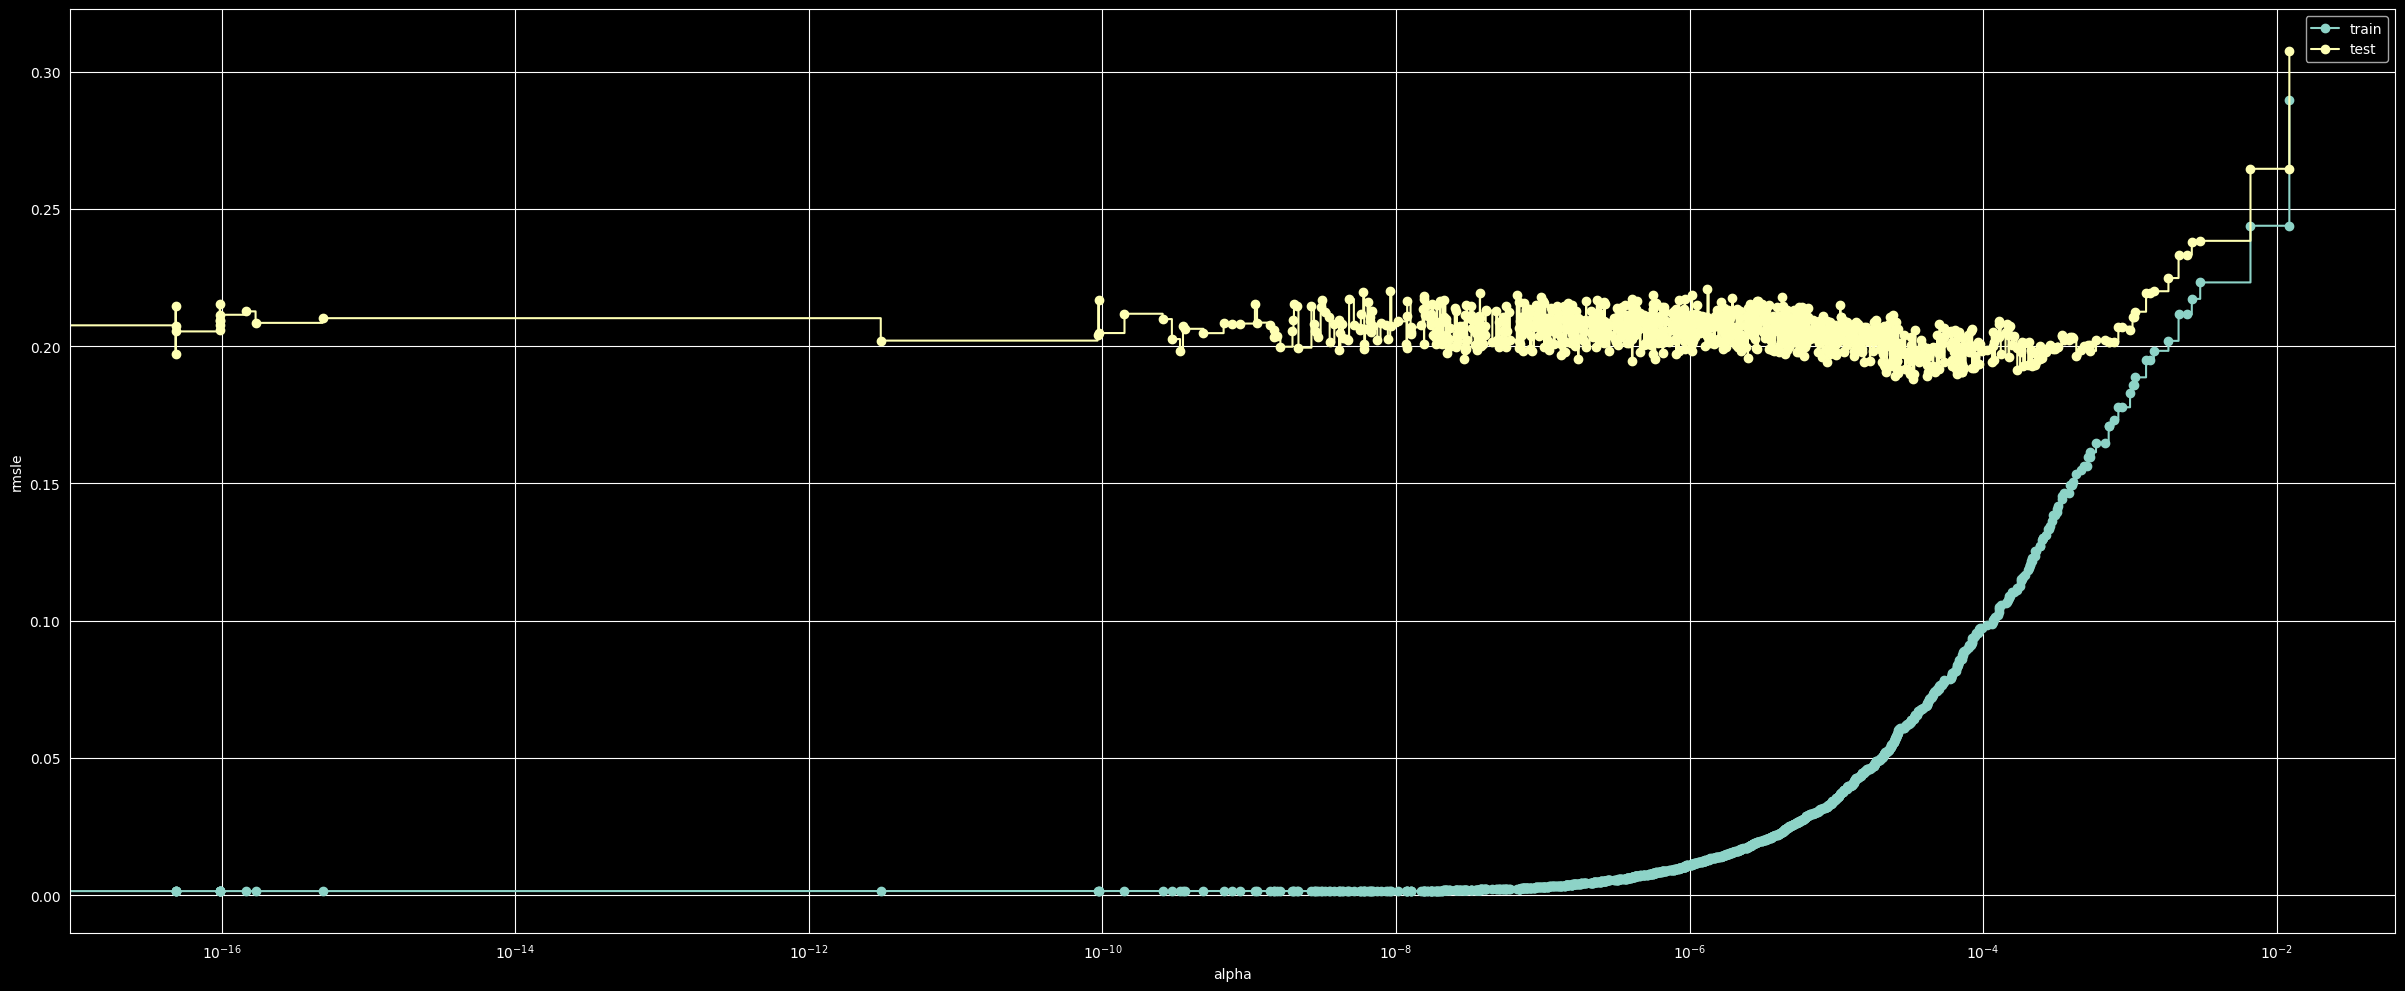

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

train_scores = [root_mean_squared_error(reg_dt.predict(X_train_t), y_train_log) for reg_dt in reg_dts]
test_scores = [root_mean_squared_error(reg_dt.predict(X_test_t), y_test_log) for reg_dt in reg_dts]


flg, ax = plt.subplots(figsize=(30, 12))
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('rmsle')
ax.plot(ccp_alphas, train_scores, marker='o', label='train', drawstyle='steps-post')
ax.plot(ccp_alphas, test_scores, marker='o', label='test', drawstyle='steps-post')
ax.legend()
plt.show()

In [107]:
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

alpha_loop_values = []

for ccp_alpha in ccp_alphas:
    reg_dt = DecisionTreeRegressor(ccp_alpha=ccp_alpha, random_state=42)

    cv_scores = cross_val_score(
        reg_dt, X_train_t, y_train_log,
        cv=kf,
        scoring='neg_root_mean_squared_error',
    )

    alpha_loop_values.append([ccp_alpha, np.mean(-cv_scores), np.std(-cv_scores)])

# print(alpha_loop_values)
alpha_results = pd.DataFrame(alpha_loop_values, columns=['alpha', 'mean', 'std'])

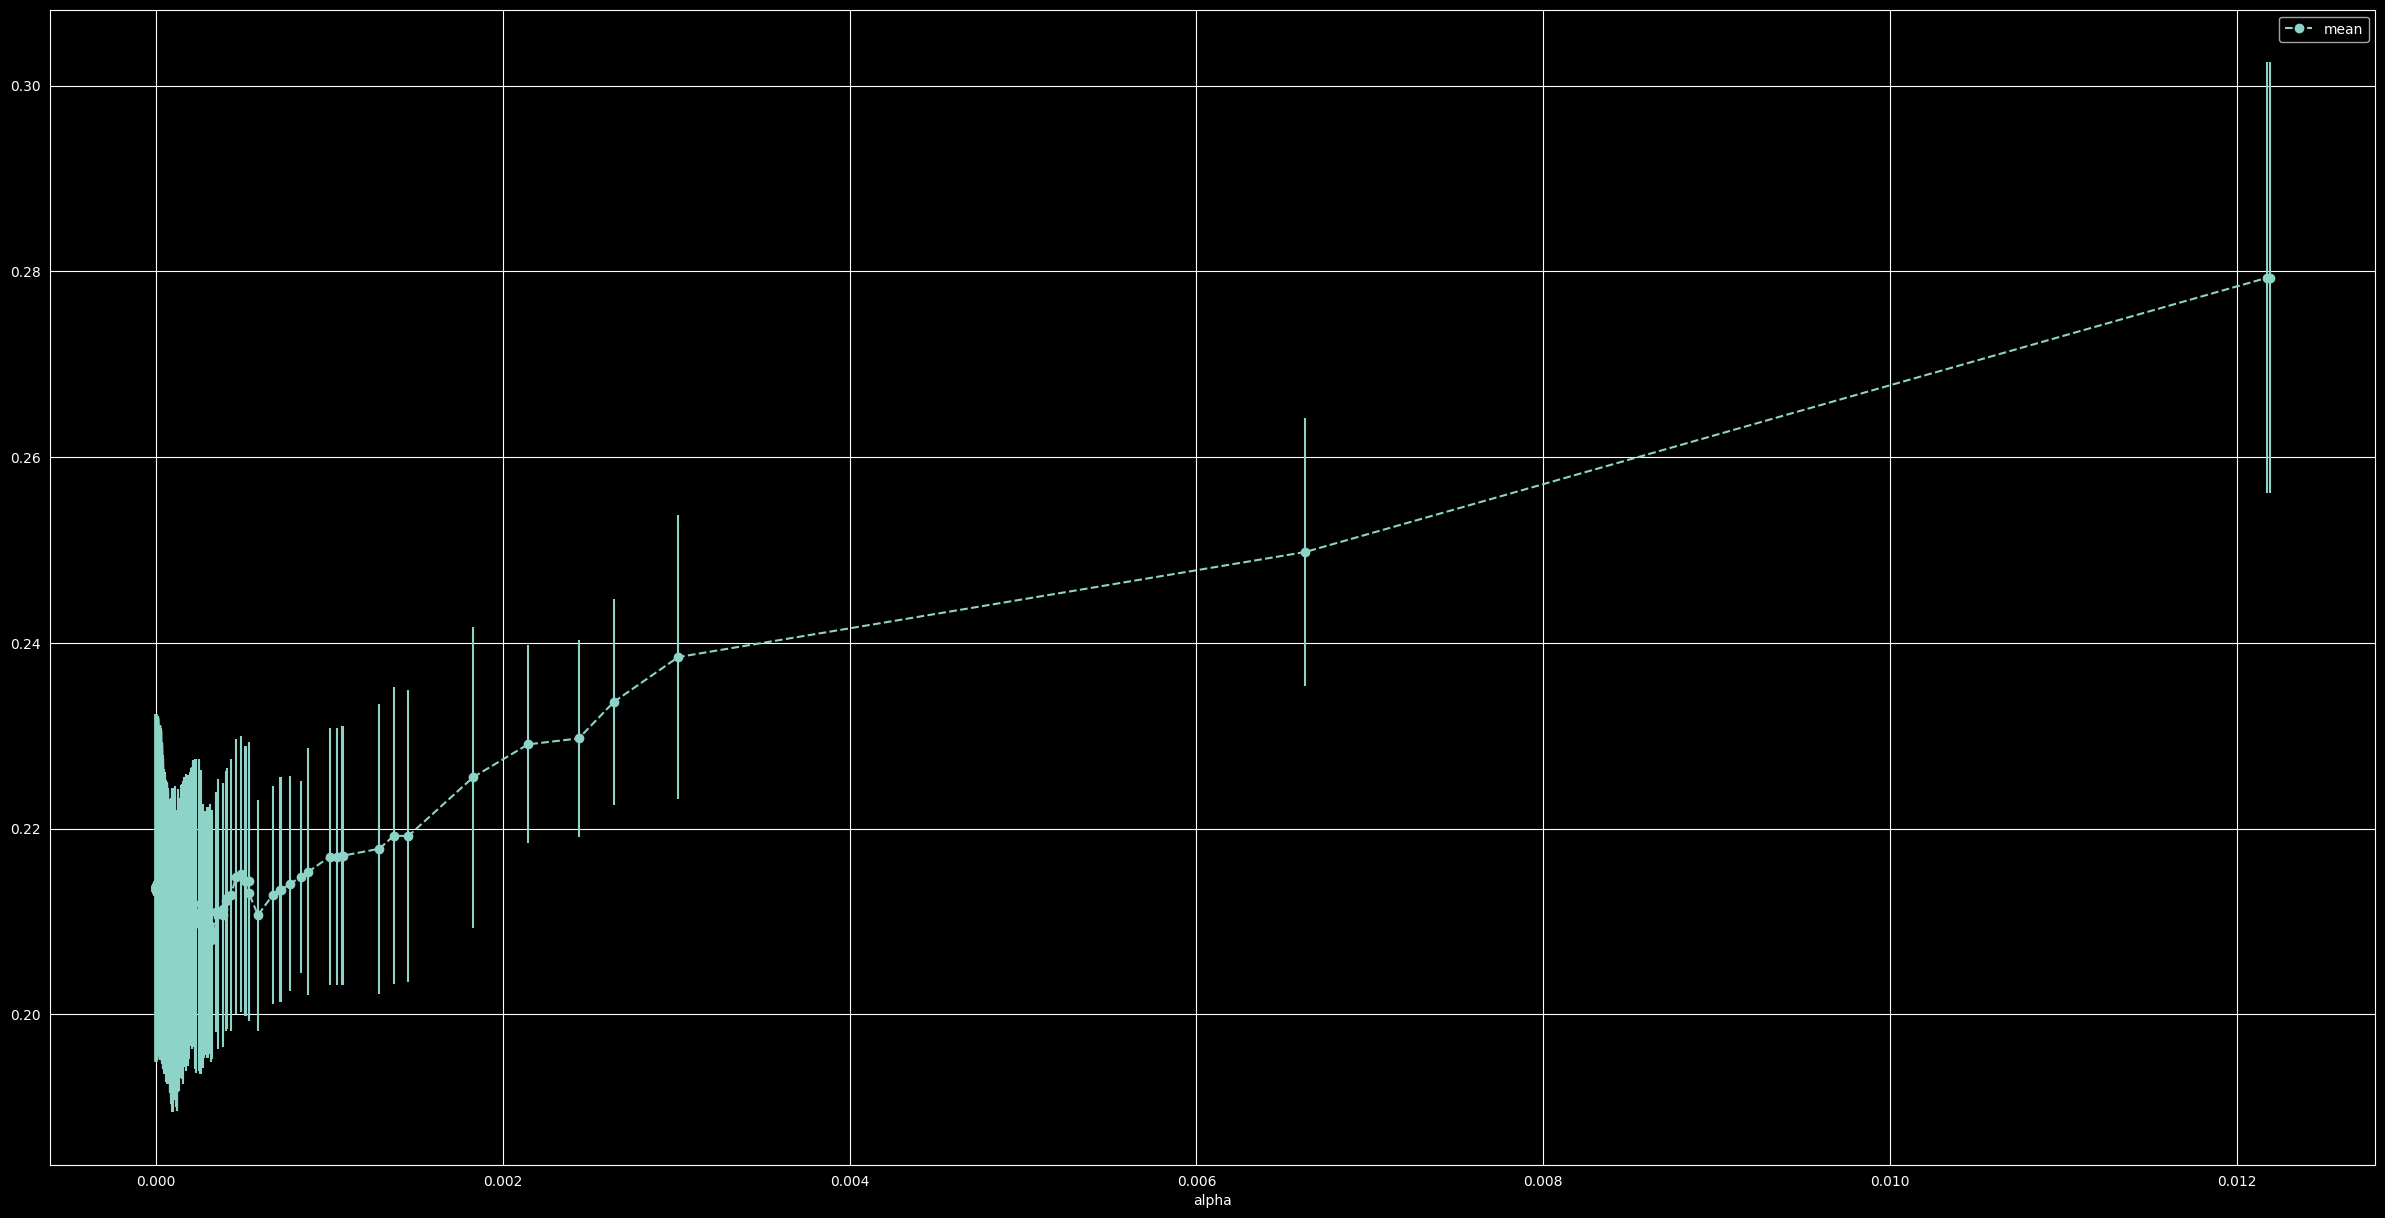

In [108]:
ax = alpha_results.plot(
    figsize=(30, 15),
    x='alpha',
    y='mean',
    yerr='std',
    marker='o',
    linestyle='--'
)

# ax.set_xscale('log')